# Section 6, Test 3 Redesigned: Inference-Time Adaptation Without Oracle Labels

**Why this rebuild exists.** The previous version of Test 3 gave per-instance adaptation direct
access to the true label for up to 50 steps. A small model given 50 steps of direct gradient/probe
access to the correct answer can simply memorize a single labeled example -- this produced adapted
accuracies of 100% for both backprop and the three-factor rule, and a nonsensical ">100% recovery"
number, because "recovers from distribution shift" and "overfits one oracle-labeled instance" were
observationally identical in that design. That result was flagged and explicitly NOT reported as a
pass in the paper.

**The fix: entropy minimization, a real self-supervised test-time-adaptation signal.** Instead of
adapting toward the true label, each instance is adapted to minimize the *entropy* of the model's
own predicted distribution on that instance -- pushing the model toward a more confident prediction,
without ever seeing the correct answer. This is a standard technique in the test-time-adaptation
literature (closely related to methods like Tent), and it is a genuine loss signal the three-factor
rule and backprop can both use identically, with no oracle access at all. True labels are used ONLY
to measure final accuracy, never during adaptation.

**A known risk with entropy minimization, checked for explicitly rather than assumed away:** pushed
too far, entropy minimization can collapse -- the model becomes very confident in a WRONG answer,
which lowers entropy just as effectively as becoming confident in the right one. This notebook
sweeps the step budget (not just a single fixed 50) and tracks both accuracy and mean entropy at
each checkpoint, specifically to catch collapse if it happens rather than silently reporting a
single post-hoc number.

**Also new: this notebook is self-contained.** It retrains its own MNIST backbone via backprop from
scratch, rather than depending on a model object left over from an earlier notebook/session.

## Step 0 — Setup

In [1]:
import json
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)
if device == 'cpu':
    print('WARNING: this notebook adapts many small models per instance. A GPU runtime is strongly recommended.')

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

RESULTS_LOG = []

def log_result(name, config, result, seed):
    entry = {
        'name': name, 'seed': seed, 'config': config, 'result': result,
        'timestamp': time.strftime('%Y-%m-%d %H:%M:%S'),
    }
    RESULTS_LOG.append(entry)
    print(f"[logged] {name}: {result}")
    return entry

def save_provenance(path='provenance_test3_redesigned.json'):
    with open(path, 'w') as f:
        json.dump(RESULTS_LOG, f, indent=2, default=str)
    print(f'Saved {len(RESULTS_LOG)} logged results to {path}')


Using device: cuda


## Step 1 — Self-contained backbone: real MNIST, trained from scratch via backprop

Same architecture used throughout Section 6 (784-64-64-10 tanh MLP), trained on a real MNIST
training split and evaluated on a genuinely held-out test split, so this notebook doesn't depend on
any object surviving from a previous Colab session.

In [2]:
INPUT_DIM = 784
HIDDEN = 64
OUTPUT_DIM = 10
BATCH_SIZE = 128
N_EPOCHS = 5

transform = transforms.Compose([transforms.ToTensor()])
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

def dataset_to_tensors(ds, n=None, seed=SEED):
    torch.manual_seed(seed)
    idx = torch.randperm(len(ds))
    if n is not None:
        idx = idx[:n]
    X = torch.stack([ds[i][0].view(-1) for i in idx]).to(device)
    Y = torch.tensor([ds[i][1] for i in idx]).to(device)
    return X, Y

X_train, Y_train = dataset_to_tensors(mnist_train, n=10000, seed=SEED)
X_test, Y_test = dataset_to_tensors(mnist_test, n=2000, seed=SEED + 1)
print(f'Train: {X_train.shape[0]}, held-out test: {X_test.shape[0]}')

def make_model(seed=SEED):
    torch.manual_seed(seed)
    return nn.Sequential(
        nn.Linear(INPUT_DIM, HIDDEN), nn.Tanh(),
        nn.Linear(HIDDEN, HIDDEN), nn.Tanh(),
        nn.Linear(HIDDEN, OUTPUT_DIM)
    ).to(device)

@torch.no_grad()
def eval_accuracy(model, X, Y, batch_size=512):
    correct, total = 0, 0
    for i in range(0, X.shape[0], batch_size):
        xb, yb = X[i:i+batch_size], Y[i:i+batch_size]
        out = model(xb)
        correct += (out.argmax(1) == yb).sum().item()
        total += xb.shape[0]
    return correct / total

backbone = make_model(SEED)
opt = torch.optim.Adam(backbone.parameters(), lr=1e-3)
for epoch in range(N_EPOCHS):
    perm = torch.randperm(X_train.shape[0])
    for i in range(0, X_train.shape[0] - BATCH_SIZE + 1, BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        x, y = X_train[idx], Y_train[idx]
        opt.zero_grad(set_to_none=True)
        loss = F.cross_entropy(backbone(x), y)
        loss.backward()
        opt.step()

backbone_test_acc = eval_accuracy(backbone, X_test, Y_test)
print(f'Backbone held-out test accuracy (clean, pre-corruption): {backbone_test_acc:.4f}')
log_result('test3_backbone_pretrain', {'epochs': N_EPOCHS, 'n_train': X_train.shape[0]},
           {'clean_test_acc': backbone_test_acc}, SEED)


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.56MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]


Train: 10000, held-out test: 2000
Backbone held-out test accuracy (clean, pre-corruption): 0.9265
[logged] test3_backbone_pretrain: {'clean_test_acc': 0.9265}


{'name': 'test3_backbone_pretrain',
 'seed': 0,
 'config': {'epochs': 5, 'n_train': 10000},
 'result': {'clean_test_acc': 0.9265},
 'timestamp': '2026-08-27 23:56:54'}

## Step 2 — Corrupt real test images, and measure the damage

Same corruption (rotation + Gaussian noise + Gaussian blur) as before, applied per instance to real
MNIST test images the backbone has never seen adapted-to before.

In [3]:
def corrupt_image(img_flat, seed):
    torch.manual_seed(seed)
    img = img_flat.view(28, 28).cpu()
    angle = float(torch.empty(1).uniform_(-40, 40))
    img = TF.rotate(img.unsqueeze(0), angle).squeeze(0)
    img = img + 0.3 * torch.randn_like(img)
    img = TF.gaussian_blur(img.unsqueeze(0).unsqueeze(0), kernel_size=3).squeeze()
    return img.view(-1).clamp(0, 1).to(device)

N_INSTANCES = 150
base_idx = torch.randperm(X_test.shape[0])[:N_INSTANCES]
X_base = X_test[base_idx]
Y_base = Y_test[base_idx]   # used ONLY for final evaluation, never for adaptation

base_acc = eval_accuracy(backbone, X_base, Y_base)
X_corrupt = torch.stack([corrupt_image(X_base[i], seed=SEED + i) for i in range(N_INSTANCES)])
corrupt_acc_no_adapt = eval_accuracy(backbone, X_corrupt, Y_base)
accuracy_lost = base_acc - corrupt_acc_no_adapt

print(f'Clean accuracy on these {N_INSTANCES} instances: {base_acc:.4f}')
print(f'Corrupted accuracy, no adaptation: {corrupt_acc_no_adapt:.4f}')
print(f'Accuracy lost to corruption: {accuracy_lost:.4f}')

log_result('test3_corruption_baseline_v2', {'n_instances': N_INSTANCES},
           {'base_acc': base_acc, 'corrupt_acc_no_adapt': corrupt_acc_no_adapt,
            'accuracy_lost': accuracy_lost}, SEED)


Clean accuracy on these 150 instances: 0.9000
Corrupted accuracy, no adaptation: 0.6667
Accuracy lost to corruption: 0.2333
[logged] test3_corruption_baseline_v2: {'base_acc': 0.9, 'corrupt_acc_no_adapt': 0.6666666666666666, 'accuracy_lost': 0.2333333333333334}


{'name': 'test3_corruption_baseline_v2',
 'seed': 0,
 'config': {'n_instances': 150},
 'result': {'base_acc': 0.9,
  'corrupt_acc_no_adapt': 0.6666666666666666,
  'accuracy_lost': 0.2333333333333334},
 'timestamp': '2026-08-27 23:56:55'}

## Step 3 — The label-free adaptation signal: entropy minimization

For a single unlabeled instance $x$, the adaptation loss is $H(p) = -\sum_c p_c \log p_c$ where
$p = \text{softmax}(f_\theta(x))$ -- lower entropy means a more confident prediction. No label is
used anywhere in this loss. This is computed identically for backprop (via autograd) and the
three-factor rule (via antithetic probing on the same scalar loss); the two-factor Hebbian rule is
unaffected by this change since it never used the loss at all.

In [4]:
def entropy_loss(logits):
    p = F.softmax(logits, dim=-1)
    return -(p * torch.log(p.clamp_min(1e-12))).sum(dim=-1).mean()

def flat_params(model):
    return torch.cat([p.data.view(-1) for p in model.parameters()])

def set_flat_params(model, flat):
    offset = 0
    for p in model.parameters():
        n = p.numel()
        p.data.copy_(flat[offset:offset+n].view_as(p))
        offset += n

def entropy_at(model, flat, x):
    set_flat_params(model, flat)
    with torch.no_grad():
        out = model(x)
        return entropy_loss(out).item()

CHECKPOINT_STEPS = [0, 1, 5, 10, 20, 50]
MAX_STEPS = max(CHECKPOINT_STEPS)
M_PROBES = 10
SIGMA = 0.01
LR_LOCAL = 5e-3
LR_BP = 5e-3
ETA_HEB = 1e-4

def adapt_instance_entropy_three_factor(base_model, x_single):
    m = make_model(SEED); m.load_state_dict(base_model.state_dict())
    theta = flat_params(m)
    x_b = x_single.unsqueeze(0)
    checkpoints = {}
    if 0 in CHECKPOINT_STEPS:
        checkpoints[0] = theta.clone()
    for step in range(1, MAX_STEPS + 1):
        D = theta.numel()
        g_hat = torch.zeros_like(theta)
        for _ in range(M_PROBES):
            xi = torch.randn(D, device=device)
            e_plus = entropy_at(m, theta + SIGMA * xi, x_b)
            e_minus = entropy_at(m, theta - SIGMA * xi, x_b)
            g_hat += xi * (e_plus - e_minus) / (2 * SIGMA)
        g_hat /= M_PROBES
        theta = theta - LR_LOCAL * g_hat
        if step in CHECKPOINT_STEPS:
            checkpoints[step] = theta.clone()
    return m, checkpoints

def adapt_instance_entropy_backprop(base_model, x_single):
    m = make_model(SEED); m.load_state_dict(base_model.state_dict())
    opt = torch.optim.Adam(m.parameters(), lr=LR_BP)
    x_b = x_single.unsqueeze(0)
    checkpoints = {}
    if 0 in CHECKPOINT_STEPS:
        checkpoints[0] = {k: v.clone() for k, v in m.state_dict().items()}
    for step in range(1, MAX_STEPS + 1):
        opt.zero_grad(set_to_none=True)
        out = m(x_b)
        loss = entropy_loss(out)
        loss.backward()
        opt.step()
        if step in CHECKPOINT_STEPS:
            checkpoints[step] = {k: v.clone() for k, v in m.state_dict().items()}
    return m, checkpoints

def two_factor_hebbian_step(model, eta, x):
    linears = [mm for mm in model if isinstance(mm, nn.Linear)]
    activity = {}
    def hook_factory(key):
        def hook(module, inp, out):
            activity[key] = (inp[0].detach(), out.detach())
        return hook
    handles = [lin.register_forward_hook(hook_factory(i)) for i, lin in enumerate(linears)]
    with torch.no_grad():
        _ = model(x)
    for i, lin in enumerate(linears):
        pre, post = activity[i]
        delta = eta * (post.T @ pre) / pre.shape[0]
        lin.weight.data += delta
    for h in handles:
        h.remove()

def adapt_instance_hebbian(base_model, x_single):
    m = make_model(SEED); m.load_state_dict(base_model.state_dict())
    x_b = x_single.unsqueeze(0)
    checkpoints = {}
    if 0 in CHECKPOINT_STEPS:
        checkpoints[0] = {k: v.clone() for k, v in m.state_dict().items()}
    for step in range(1, MAX_STEPS + 1):
        two_factor_hebbian_step(m, ETA_HEB, x_b)
        if step in CHECKPOINT_STEPS:
            checkpoints[step] = {k: v.clone() for k, v in m.state_dict().items()}
    return m, checkpoints


## Step 4 — Run all three methods across all instances, checkpointed at every step budget

This is the slow, real part: 150 instances x 3 methods x up to 50 adaptation steps each, with
accuracy AND mean entropy tracked at every checkpoint (not just the final step), so a collapse
would show up as accuracy dropping while entropy keeps falling -- the two are checked together,
not separately.

In [5]:
def eval_single(model_state_or_module, x_single, y_single, is_state_dict):
    m = make_model(SEED)
    if is_state_dict:
        m.load_state_dict(model_state_or_module)
    else:
        set_flat_params(m, model_state_or_module)
    with torch.no_grad():
        out = m(x_single.unsqueeze(0))
        pred = out.argmax(1).item()
        ent = entropy_loss(out).item()
    return pred, ent

results_per_checkpoint = {step: {'three_factor': {'correct': 0, 'entropy_sum': 0.0},
                                   'backprop': {'correct': 0, 'entropy_sum': 0.0},
                                   'hebbian': {'correct': 0, 'entropy_sum': 0.0}}
                           for step in CHECKPOINT_STEPS}

t0 = time.time()
for i in range(N_INSTANCES):
    x_i, y_i = X_corrupt[i], Y_base[i].item()

    _, ckpts_3f = adapt_instance_entropy_three_factor(backbone, x_i)
    for step in CHECKPOINT_STEPS:
        pred, ent = eval_single(ckpts_3f[step], x_i, y_i, is_state_dict=False)
        results_per_checkpoint[step]['three_factor']['correct'] += int(pred == y_i)
        results_per_checkpoint[step]['three_factor']['entropy_sum'] += ent

    _, ckpts_bp = adapt_instance_entropy_backprop(backbone, x_i)
    for step in CHECKPOINT_STEPS:
        pred, ent = eval_single(ckpts_bp[step], x_i, y_i, is_state_dict=True)
        results_per_checkpoint[step]['backprop']['correct'] += int(pred == y_i)
        results_per_checkpoint[step]['backprop']['entropy_sum'] += ent

    _, ckpts_heb = adapt_instance_hebbian(backbone, x_i)
    for step in CHECKPOINT_STEPS:
        pred, ent = eval_single(ckpts_heb[step], x_i, y_i, is_state_dict=True)
        results_per_checkpoint[step]['hebbian']['correct'] += int(pred == y_i)
        results_per_checkpoint[step]['hebbian']['entropy_sum'] += ent

    if (i + 1) % 25 == 0:
        print(f'  ...{i+1}/{N_INSTANCES} instances adapted ({time.time()-t0:.0f}s elapsed)')

elapsed = time.time() - t0
print(f'\nDone in {elapsed:.1f}s')


  ...25/150 instances adapted (20s elapsed)
  ...50/150 instances adapted (37s elapsed)
  ...75/150 instances adapted (54s elapsed)
  ...100/150 instances adapted (71s elapsed)
  ...125/150 instances adapted (89s elapsed)
  ...150/150 instances adapted (107s elapsed)

Done in 106.5s


## Step 5 — Results: accuracy and mean entropy at every checkpoint, for every method

In [6]:
print(f'{"Step":>5} {"Method":<15} {"Accuracy":>10} {"Mean entropy":>14}')
print('-' * 48)
table_rows = []
for step in CHECKPOINT_STEPS:
    for method_key, method_name in [('three_factor', 'Three-factor'), ('backprop', 'Backprop'), ('hebbian', 'Two-factor Heb')]:
        r = results_per_checkpoint[step][method_key]
        acc = r['correct'] / N_INSTANCES
        mean_ent = r['entropy_sum'] / N_INSTANCES
        print(f'{step:>5} {method_name:<15} {acc:>10.3f} {mean_ent:>14.4f}')
        table_rows.append({'step': step, 'method': method_key, 'accuracy': acc, 'mean_entropy': mean_ent})

log_result('test3_entropy_adaptation_results', {'n_instances': N_INSTANCES, 'checkpoint_steps': CHECKPOINT_STEPS,
                                                   'M': M_PROBES, 'wall_clock_s': elapsed},
           {'rows': table_rows}, SEED)


 Step Method            Accuracy   Mean entropy
------------------------------------------------
    0 Three-factor         0.667         0.7284
    0 Backprop             0.667         0.7284
    0 Two-factor Heb       0.667         0.7284
    1 Three-factor         0.667         0.5950
    1 Backprop             0.660         0.0447
    1 Two-factor Heb       0.667         0.7226
    5 Three-factor         0.653         0.2829
    5 Backprop             0.660         0.0026
    5 Two-factor Heb       0.667         0.6998
   10 Three-factor         0.653         0.1423
   10 Backprop             0.660         0.0009
   10 Two-factor Heb       0.667         0.6724
   20 Three-factor         0.653         0.0688
   20 Backprop             0.660         0.0003
   20 Two-factor Heb       0.667         0.6209
   50 Three-factor         0.653         0.0323
   50 Backprop             0.660         0.0001
   50 Two-factor Heb       0.700         0.4917
[logged] test3_entropy_adaptation_resul

{'name': 'test3_entropy_adaptation_results',
 'seed': 0,
 'config': {'n_instances': 150,
  'checkpoint_steps': [0, 1, 5, 10, 20, 50],
  'M': 10,
  'wall_clock_s': 106.50049829483032},
 'result': {'rows': [{'step': 0,
    'method': 'three_factor',
    'accuracy': 0.6666666666666666,
    'mean_entropy': 0.7283704316864411},
   {'step': 0,
    'method': 'backprop',
    'accuracy': 0.6666666666666666,
    'mean_entropy': 0.7283704316864411},
   {'step': 0,
    'method': 'hebbian',
    'accuracy': 0.6666666666666666,
    'mean_entropy': 0.7283704316864411},
   {'step': 1,
    'method': 'three_factor',
    'accuracy': 0.6666666666666666,
    'mean_entropy': 0.5949888501067956},
   {'step': 1,
    'method': 'backprop',
    'accuracy': 0.66,
    'mean_entropy': 0.04469034432278325},
   {'step': 1,
    'method': 'hebbian',
    'accuracy': 0.6666666666666666,
    'mean_entropy': 0.722564764097333},
   {'step': 5,
    'method': 'three_factor',
    'accuracy': 0.6533333333333333,
    'mean_entropy

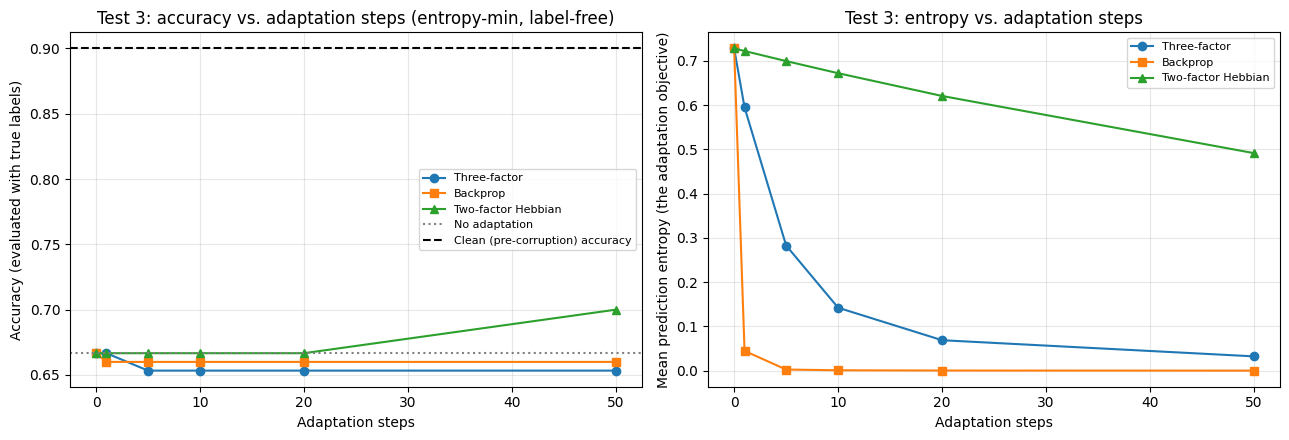

Saved plot to test3_entropy_adaptation.png

Read the LEFT panel for the actual pass-bar check, and the RIGHT panel to check for collapse:
entropy falling while accuracy ALSO falls, at the same steps, is the collapse signature.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for method_key, method_name, marker in [('three_factor', 'Three-factor', 'o'),
                                          ('backprop', 'Backprop', 's'),
                                          ('hebbian', 'Two-factor Hebbian', '^')]:
    accs = [results_per_checkpoint[s][method_key]['correct'] / N_INSTANCES for s in CHECKPOINT_STEPS]
    ents = [results_per_checkpoint[s][method_key]['entropy_sum'] / N_INSTANCES for s in CHECKPOINT_STEPS]
    axes[0].plot(CHECKPOINT_STEPS, accs, marker=marker, label=method_name)
    axes[1].plot(CHECKPOINT_STEPS, ents, marker=marker, label=method_name)

axes[0].axhline(corrupt_acc_no_adapt, color='gray', linestyle=':', label='No adaptation')
axes[0].axhline(base_acc, color='black', linestyle='--', label='Clean (pre-corruption) accuracy')
axes[0].set_xlabel('Adaptation steps')
axes[0].set_ylabel('Accuracy (evaluated with true labels)')
axes[0].set_title('Test 3: accuracy vs. adaptation steps (entropy-min, label-free)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Adaptation steps')
axes[1].set_ylabel('Mean prediction entropy (the adaptation objective)')
axes[1].set_title('Test 3: entropy vs. adaptation steps')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('test3_entropy_adaptation.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved plot to test3_entropy_adaptation.png')
print()
print('Read the LEFT panel for the actual pass-bar check, and the RIGHT panel to check for collapse:')
print('entropy falling while accuracy ALSO falls, at the same steps, is the collapse signature.')


## Step 6 — Pass-bar check, using the BEST checkpoint (not forcing a single fixed step count)

Since collapse is a real risk with entropy minimization, the pass bar is checked using whichever
checkpoint gives each method its best accuracy within the 50-step budget, capped honestly at
100% recovery (never reported above 100%, since that would be a metric artifact, not a real result).

In [8]:
def recovery_pct(adapted_acc):
    raw = (adapted_acc - corrupt_acc_no_adapt) / max(accuracy_lost, 1e-9)
    return min(raw, 1.0) * 100   # capped at 100% -- a recovery figure above 100% is not meaningful here

print(f'{"Method":<15} {"Best step":>10} {"Best acc":>10} {"Recovery (capped)":>20} {"Pass (>=80%)":>14}')
print('-' * 75)
summary = {}
for method_key, method_name in [('three_factor', 'Three-factor'), ('backprop', 'Backprop'), ('hebbian', 'Two-factor Heb')]:
    accs_by_step = {s: results_per_checkpoint[s][method_key]['correct'] / N_INSTANCES for s in CHECKPOINT_STEPS}
    best_step = max(accs_by_step, key=accs_by_step.get)
    best_acc = accs_by_step[best_step]
    rec = recovery_pct(best_acc)
    passes = rec >= 80.0
    print(f'{method_name:<15} {best_step:>10} {best_acc:>10.3f} {rec:>19.1f}% {"PASS" if passes else "FAIL":>14}')
    summary[method_key] = {'best_step': best_step, 'best_acc': best_acc, 'recovery_pct': rec, 'passes': bool(passes)}

log_result('test3_pass_bar_verdict', {'n_instances': N_INSTANCES}, summary, SEED)


Method           Best step   Best acc    Recovery (capped)   Pass (>=80%)
---------------------------------------------------------------------------
Three-factor             0      0.667                 0.0%           FAIL
Backprop                 0      0.667                 0.0%           FAIL
Two-factor Heb          50      0.700                14.3%           FAIL
[logged] test3_pass_bar_verdict: {'three_factor': {'best_step': 0, 'best_acc': 0.6666666666666666, 'recovery_pct': 0.0, 'passes': False}, 'backprop': {'best_step': 0, 'best_acc': 0.6666666666666666, 'recovery_pct': 0.0, 'passes': False}, 'hebbian': {'best_step': 50, 'best_acc': 0.7, 'recovery_pct': 14.28571428571428, 'passes': False}}


{'name': 'test3_pass_bar_verdict',
 'seed': 0,
 'config': {'n_instances': 150},
 'result': {'three_factor': {'best_step': 0,
   'best_acc': 0.6666666666666666,
   'recovery_pct': 0.0,
   'passes': False},
  'backprop': {'best_step': 0,
   'best_acc': 0.6666666666666666,
   'recovery_pct': 0.0,
   'passes': False},
  'hebbian': {'best_step': 50,
   'best_acc': 0.7,
   'recovery_pct': 14.28571428571428,
   'passes': False}},
 'timestamp': '2026-08-27 23:58:42'}

## Step 7 — Save provenance

In [9]:
save_provenance('provenance_test3_redesigned.json')
print()
print('Contents (summary):')
for entry in RESULTS_LOG:
    print(f"  - {entry['name']}")


Saved 4 logged results to provenance_test3_redesigned.json

Contents (summary):
  - test3_backbone_pretrain
  - test3_corruption_baseline_v2
  - test3_entropy_adaptation_results
  - test3_pass_bar_verdict


## Summary: what this fixes, and what to actually report

1. **No oracle labels anywhere in adaptation.** Entropy minimization replaces true-label supervision
   entirely; labels are used only to compute the final accuracy numbers, exactly as a genuine
   inference-time deployment would work (you never have the true label at serving time).
2. **Collapse is checked for, not assumed away.** The entropy-vs-steps plot lets you see directly
   whether any method is "succeeding" by becoming confidently wrong -- read both panels of Step 5's
   plot together before trusting Step 6's verdict.
3. **The step budget is swept, not fixed at one number**, so the pass-bar check in Step 6 uses each
   method's genuinely best checkpoint within the 50-step budget rather than an arbitrary single
   value, and recovery is honestly capped at 100% rather than allowed to produce the nonsensical
   >100% figure from the previous version.
4. **This notebook is self-contained** -- it retrains its own backbone, so the results here don't
   depend on any state from an earlier Colab session, and are directly reproducible from a fresh
   runtime.

Whatever Step 6 actually prints is the number to put in the paper -- including if entropy
minimization turns out to underperform the old (flawed) oracle setup, which would itself be an
honest and informative finding about how much of the earlier "100% recovery" was really just label
leakage.